In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import warnings
warnings.filterwarnings('ignore')

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["aqi_db"]
df = pd.DataFrame(list(db.features.find()))

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\n Columns: {df.columns.tolist()}")

Dataset Shape: (717, 31)
Date Range: 2026-05-01 23:14:38.403000 to 2026-05-31 19:14:38.403000

 Columns: ['_id', 'timestamp', 'city', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'wind_speed', 'hour', 'day_of_week', 'month', 'is_weekend', 'pm25_lag1', 'pm25_lag3', 'pm25_roll_mean3', 'pm25_roll_std3', 'pm10_lag1', 'pm10_lag3', 'pm10_roll_mean3', 'pm10_roll_std3', 'aqi_lag1', 'aqi_lag3', 'aqi_roll_mean3', 'aqi_roll_std3', 'aqi_change_rate', 'pm_ratio', 'target_aqi']


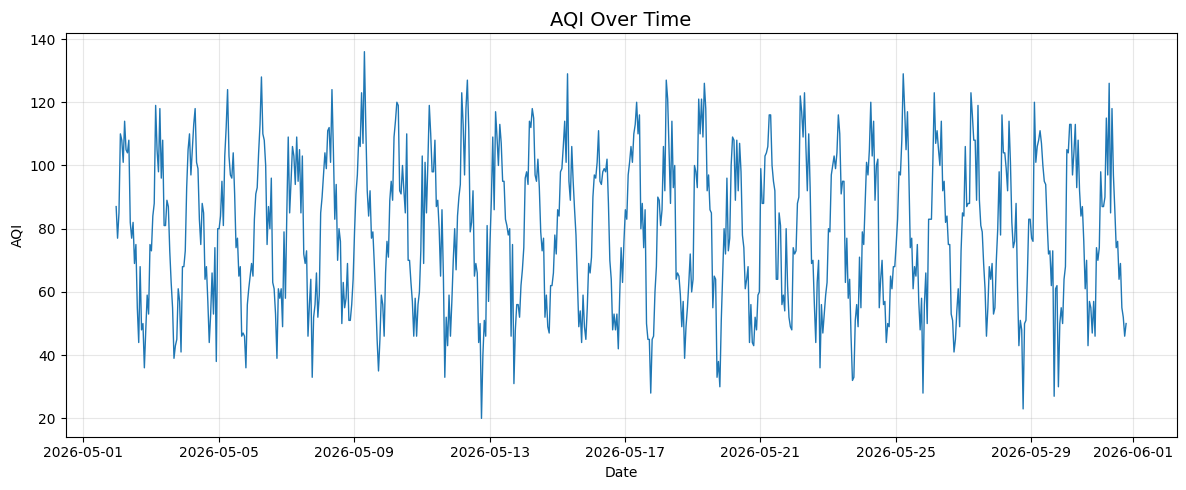

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'], df['target_aqi'], linewidth=1)
plt.title('AQI Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

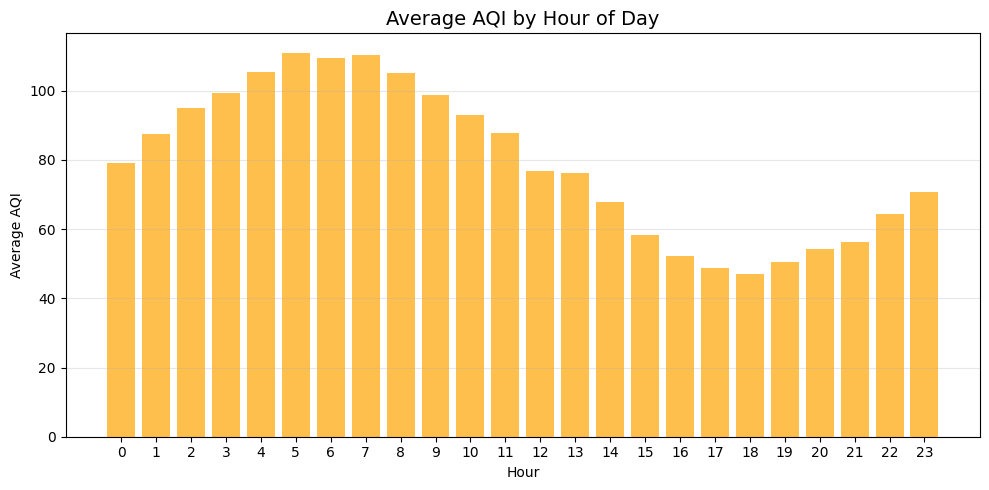

In [3]:
plt.figure(figsize=(10, 5))
hourly_avg = df.groupby('hour')['target_aqi'].mean()
plt.bar(hourly_avg.index, hourly_avg.values, color='orange', alpha=0.7)
plt.title('Average AQI by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

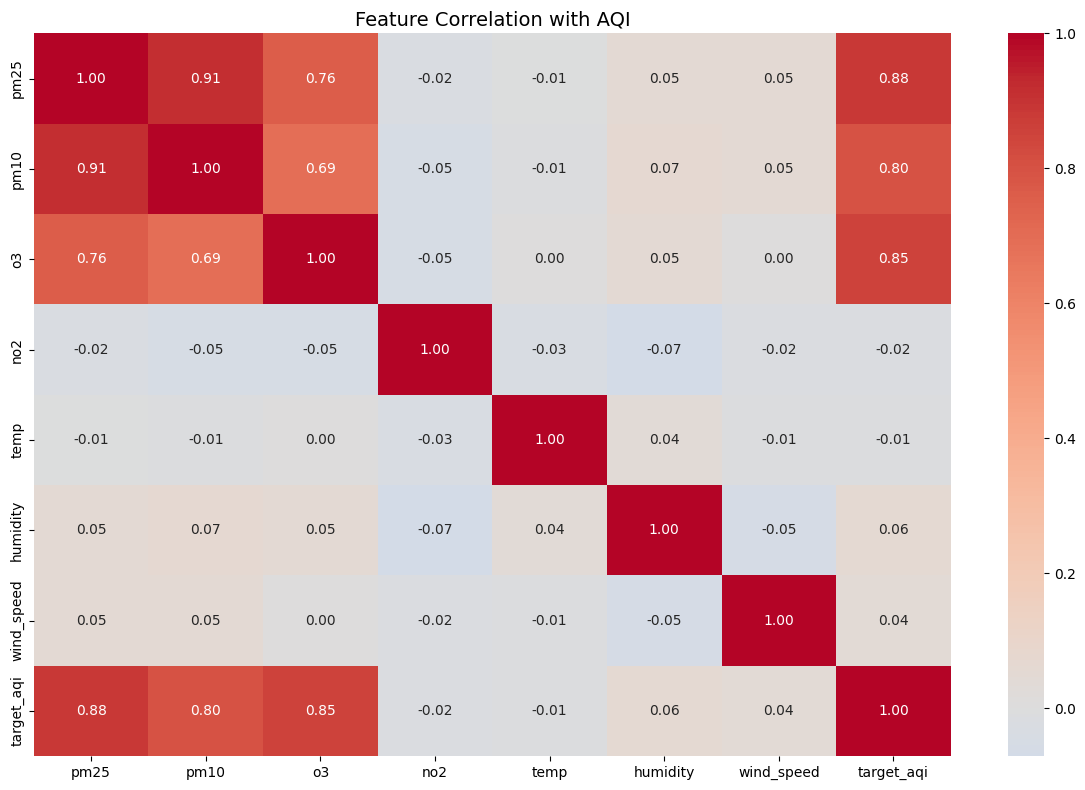

In [4]:
plt.figure(figsize=(12, 8))
corr_cols = ['pm25', 'pm10', 'o3', 'no2', 'temp', 'humidity', 'wind_speed', 'target_aqi']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation with AQI', fontsize=14)
plt.tight_layout()
plt.show()

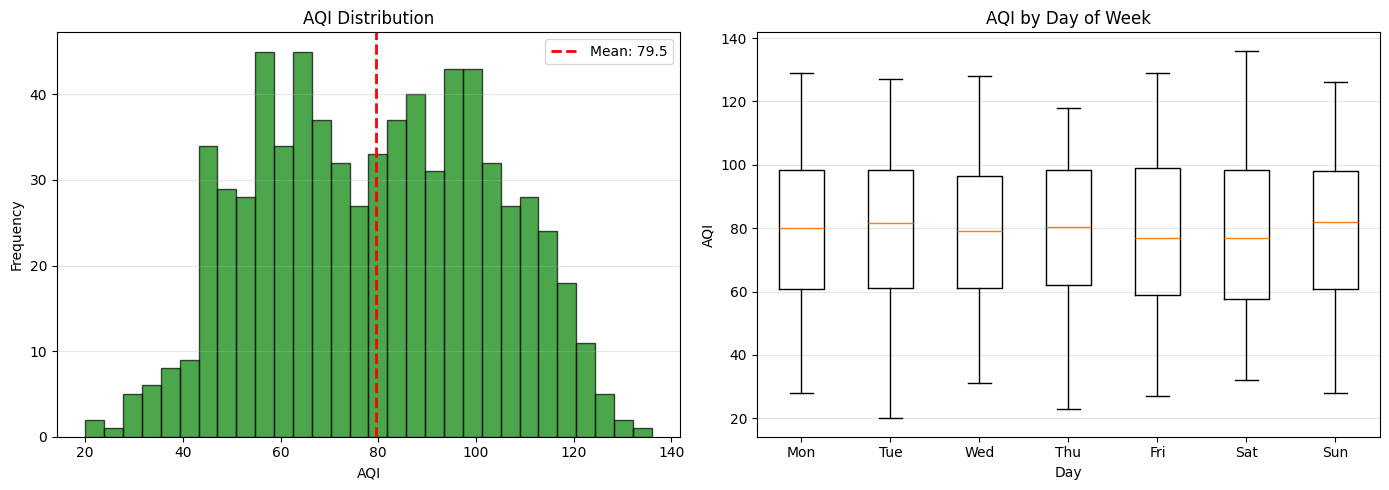

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['target_aqi'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(df['target_aqi'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["target_aqi"].mean():.1f}')
axes[0].set_title('AQI Distribution', fontsize=12)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_temp = df.copy()
df_temp['day_name'] = df_temp['day_of_week'].map(dict(enumerate(day_names)))
axes[1].boxplot([df_temp[df_temp['day_of_week']==i]['target_aqi'].dropna() for i in range(7)], labels=day_names)
axes[1].set_title('AQI by Day of Week', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('AQI')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

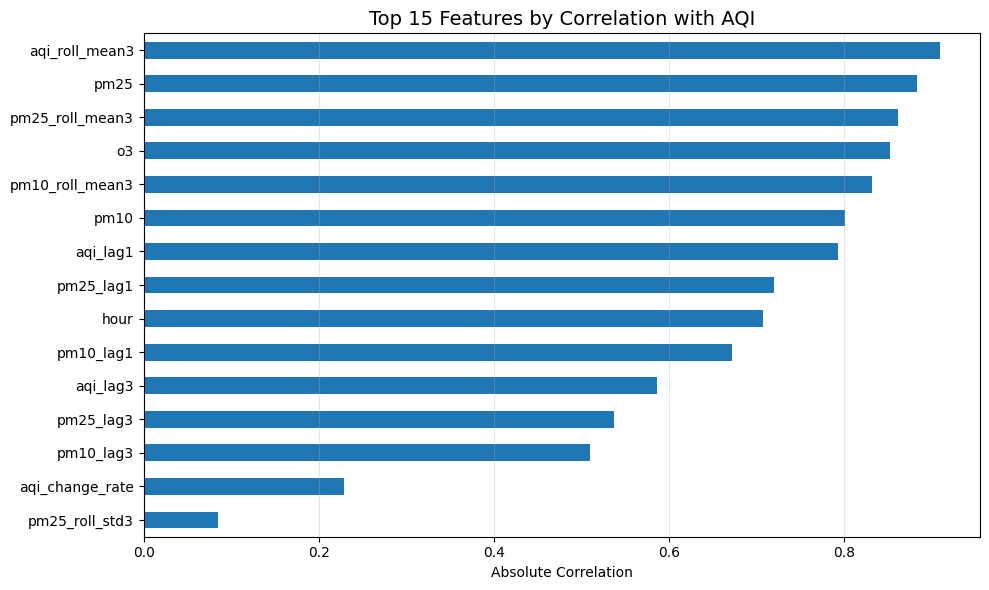

Top Correlated Features:
aqi_roll_mean3     0.909494
pm25               0.883321
pm25_roll_mean3    0.861025
o3                 0.852493
pm10_roll_mean3    0.831249
pm10               0.801001
aqi_lag1           0.792950
pm25_lag1          0.720049
hour               0.707389
pm10_lag1          0.671406
Name: target_aqi, dtype: float64


In [6]:
feature_cols = [c for c in df.columns if c not in ['_id', 'timestamp', 'city', 'target_aqi']]
correlations = df[feature_cols + ['target_aqi']].corr()['target_aqi'].drop('target_aqi').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='barh')
plt.title('Top 15 Features by Correlation with AQI', fontsize=14)
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top Correlated Features:")
print(correlations.head(10))